<a href="https://colab.research.google.com/github/DeepthiManthapuram/Deep_Learning/blob/main/news_summary_Translator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sunnysai12345/news-summary")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'news-summary' dataset.
Path to dataset files: /kaggle/input/news-summary


Problem Statement
A software company conducts:
Daily standup meetings
Sprint planning meetings
Client discussions
Project review meetings
Employees don't have time to read long meeting notes.
The company wants an AI system that automatically generates concise summaries.
You are hired as an AI Engineer to build a Seq2Seq Encoder-Decoder based Meeting Notes Summarizer.

Long Meeting Notes

        ↓

Encoder

        ↓

Context Vector

        ↓

Decoder

        ↓

Short Summary

Tasks
Task 1
Perform EDA
Analyze:
number of records
average article length
average summary length


Dataset Shape: (4514, 6)

Number of Records: 4514

Columns:
Index(['author', 'date', 'headlines', 'read_more', 'text', 'ctext'], dtype='object')

Missing Values:
author         0
date           0
headlines      0
read_more      0
text           0
ctext        118
dtype: int64

Average Article Length: 58.29 words
Average Summary Length: 9.29 words

Article Length Statistics:
count    4514.000000
mean       58.287328
std         2.320266
min        44.000000
25%        57.000000
50%        59.000000
75%        60.000000
max        62.000000
Name: article_length, dtype: float64

Summary Length Statistics:
count    4514.000000
mean        9.293974
std         1.408318
min         4.000000
25%         8.000000
50%         9.000000
75%        10.000000
max        14.000000
Name: summary_length, dtype: float64


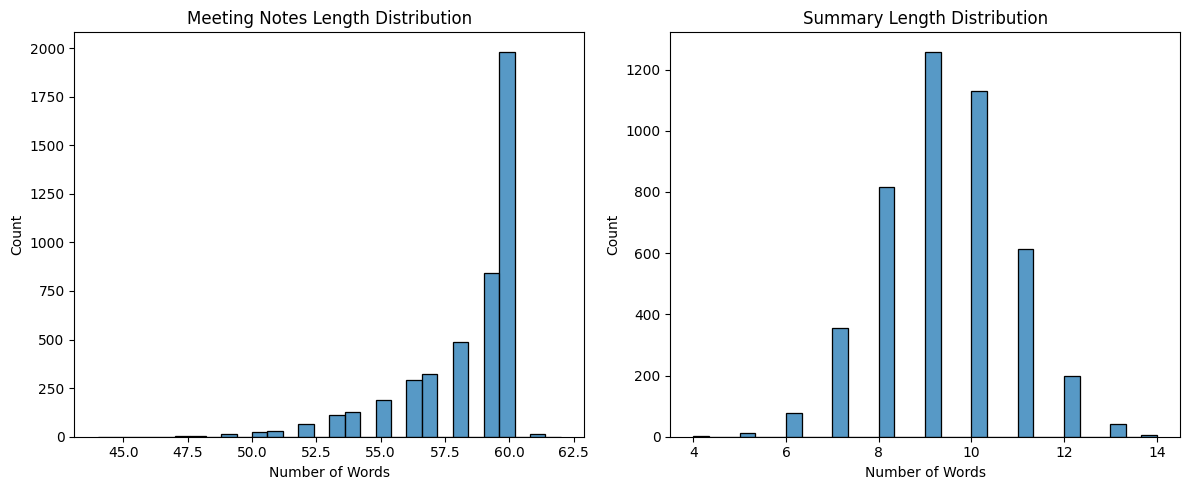


Average Compression Ratio: 0.16


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load dataset
file_path = os.path.join(path, "news_summary.csv")
df = pd.read_csv(file_path, encoding='latin1')

# ---------------------------
# Basic Dataset Information
# ---------------------------
print("Dataset Shape:", df.shape)
print("\nNumber of Records:", len(df))

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

# ---------------------------
# Text Length Analysis
# ---------------------------

# Count words in meeting notes (using 'text' column)
df['article_length'] = df['text'].apply(
    lambda x: len(str(x).split())
)

# Count words in summaries (using 'headlines' column)
df['summary_length'] = df['headlines'].apply(
    lambda x: len(str(x).split())
)

# Average lengths
avg_article_length = df['article_length'].mean()
avg_summary_length = df['summary_length'].mean()

print("\nAverage Article Length:", round(avg_article_length, 2), "words")
print("Average Summary Length:", round(avg_summary_length, 2), "words")

# ---------------------------
# Additional Statistics
# ---------------------------

print("\nArticle Length Statistics:")
print(df['article_length'].describe())

print("\nSummary Length Statistics:")
print(df['summary_length'].describe())

# ---------------------------
# Visualization
# ---------------------------

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['article_length'], bins=30)
plt.title("Meeting Notes Length Distribution")
plt.xlabel("Number of Words")

plt.subplot(1,2,2)
sns.histplot(df['summary_length'], bins=30)
plt.title("Summary Length Distribution")
plt.xlabel("Number of Words")

plt.tight_layout()
plt.show()

# ---------------------------
# Compression Ratio
# ---------------------------

df['compression_ratio'] = (
    df['summary_length'] / df['article_length']
)

print("\nAverage Compression Ratio:",
      round(df['compression_ratio'].mean(), 3))

**Task 2**
Text Preprocessing
Apply:
lowercase conversion
punctuation removal
tokenization
padding

In [ ]:
import pandas as pd
import re
import string

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning
df['text'] = df['text'].apply(clean_text)
df['headlines'] = df['headlines'].apply(clean_text)

In [ ]:
df['headlines'] = df['headlines'].apply(
    lambda x: '<start> ' + x + ' <end>'
)

In [ ]:
# Tokenizer for meeting notes
input_tokenizer = Tokenizer()
input_tokenizer.fit_on_texts(df['text'])

# Tokenizer for summaries
target_tokenizer = Tokenizer()
target_tokenizer.fit_on_texts(df['headlines'])

# Convert text to sequences
encoder_sequences = input_tokenizer.texts_to_sequences(
    df['text']
)

decoder_sequences = target_tokenizer.texts_to_sequences(
    df['headlines']
)

In [ ]:
input_vocab_size = len(input_tokenizer.word_index) + 1
target_vocab_size = len(target_tokenizer.word_index) + 1

print("Input Vocabulary Size:", input_vocab_size)
print("Target Vocabulary Size:", target_vocab_size)

Input Vocabulary Size: 22318
Target Vocabulary Size: 9419


In [ ]:
# Maximum lengths
max_encoder_len = max(len(seq) for seq in encoder_sequences)
max_decoder_len = max(len(seq) for seq in decoder_sequences)

print("Max Meeting Notes Length:", max_encoder_len)
print("Max Summary Length:", max_decoder_len)

# Pad sequences
encoder_input_data = pad_sequences(
    encoder_sequences,
    maxlen=max_encoder_len,
    padding='post'
)

decoder_input_data = pad_sequences(
    decoder_sequences,
    maxlen=max_decoder_len,
    padding='post'
)

Max Meeting Notes Length: 62
Max Summary Length: 16


In [ ]:
print("Encoder Input Shape:", encoder_input_data.shape)
print("Decoder Input Shape:", decoder_input_data.shape)

print("\nSample Encoder Sequence:")
print(encoder_input_data[0])

print("\nSample Decoder Sequence:")
print(decoder_input_data[0])

Encoder Input Shape: (4514, 62)
Decoder Input Shape: (4514, 16)

Sample Encoder Sequence:
[    1   961     5   254  2061  8622     6  8623     8  3829    40   291
    11   103    21  2184     9   138     2  3449  8624     2    48  1131
  3450     7     1  2062     5  6821     7   672   989     1   961    12
   627     2  2334     1   403   307   893   335     5  2508     1  3451
    22    21   292 11971    20   499     6    12   364     7   324   216
     0     0]

Sample Decoder Sequence:
[   2 2850 2851 2852  632 2853    4 1321  633    1    0    0    0    0
    0    0]


**Task 3**
Build Encoder
Requirements:
Embedding
↓
LSTM Encoder
↓
Context Vector

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM
from tensorflow.keras.models import Model

# -----------------------------
# Encoder Parameters
# -----------------------------

embedding_dim = 128
latent_dim = 256

# Input vocabulary size obtained during preprocessing
# input_vocab_size = len(input_tokenizer.word_index) + 1

# Maximum encoder sequence length
# max_encoder_len = encoder_input_data.shape[1]

# -----------------------------
# Encoder Input
# -----------------------------

encoder_inputs = Input(
    shape=(max_encoder_len,),
    name="encoder_inputs"
)

# -----------------------------
# Embedding Layer
# -----------------------------

encoder_embedding = Embedding(
    input_dim=input_vocab_size,
    output_dim=embedding_dim,
    input_length=max_encoder_len,
    name="encoder_embedding"
)(encoder_inputs)

# -----------------------------
# LSTM Encoder
# -----------------------------

encoder_lstm = LSTM(
    latent_dim,
    return_state=True,
    name="encoder_lstm"
)

encoder_outputs, state_h, state_c = encoder_lstm(
    encoder_embedding
)

# -----------------------------
# Context Vector
# -----------------------------

encoder_states = [state_h, state_c]

print("Encoder Built Successfully")

Encoder Built Successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
encoder_model = Model(
    inputs=encoder_inputs,
    outputs=encoder_states
)

encoder_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_inputs (InputLayer)     │ (None, 62)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_embedding (Embedding)   │ (None, 62, 128)        │     2,856,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ [(None, 256), (None,   │       394,240 │
│                                 │ 256), (None, 256)]     │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,250,944 (12.40 MB)

 Trainable params: 3,250,944 (12.40 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4**
Build Decoder
Requirements:
Embedding
↓
LSTM Decoder
↓
Dense Layer
↓
Summary Generation

In [ ]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense
from tensorflow.keras.models import Model

# ---------------------------------
# Decoder Input
# ---------------------------------

decoder_inputs = Input(
    shape=(max_decoder_len,), # Changed shape to match expected model input
    name="decoder_inputs"
)

# ---------------------------------
# Decoder Embedding
# ---------------------------------

decoder_embedding = Embedding(
    input_dim=target_vocab_size,
    output_dim=embedding_dim,
    # Removed input_length as it is deprecated and might cause conflicts
    name="decoder_embedding"
)(decoder_inputs)

# ---------------------------------
# Decoder LSTM
# ---------------------------------

decoder_lstm = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

# ---------------------------------
# Dense Output Layer
# ---------------------------------

decoder_dense = Dense(
    target_vocab_size,
    activation='softmax',
    name="decoder_output"
)

decoder_outputs = decoder_dense(decoder_outputs)

print("Decoder Built Successfully")

Decoder Built Successfully


In [ ]:
seq2seq_model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

seq2seq_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 16)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 62, 128)   │  2,856,704 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 16, 128)   │  1,205,632 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    394,240 │ encoder_embeddin… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 16, 256), │    394,240 │ decoder_embeddin… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 16, 9419)  │  2,420,683 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,271,499 (27.74 MB)

 Trainable params: 7,271,499 (27.74 MB)

 Non-trainable params: 0 (0.00 B)

**Task 5**
Train Seq2Seq Model
Train:
Article
↓
Summary

In [ ]:
import numpy as np

# Decoder input data (using full sequence length)
decoder_input_train = decoder_input_data

# Decoder target data (using full sequence length to match model output)
decoder_target_train = np.expand_dims(
    decoder_input_data,
    -1
)

print("Decoder Input Shape:", decoder_input_train.shape)
print("Decoder Target Shape:", decoder_target_train.shape)

Decoder Input Shape: (4514, 16)
Decoder Target Shape: (4514, 16, 1)


In [ ]:
seq2seq_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

print("Model Compiled Successfully")

Model Compiled Successfully


In [ ]:
history = seq2seq_model.fit(
    [encoder_input_data, decoder_input_train],
    decoder_target_train,
    batch_size=64,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.3555 - loss: 6.1000 - val_accuracy: 0.3868 - val_loss: 4.9241
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 182s 3s/step - accuracy: 0.4247 - loss: 4.5376 - val_accuracy: 0.4301 - val_loss: 4.5799
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 175s 3s/step - accuracy: 0.4370 - loss: 4.2552 - val_accuracy: 0.4345 - val_loss: 4.4378
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - accuracy: 0.4436 - loss: 4.0866 - val_accuracy: 0.4465 - val_loss: 4.3386
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.4560 - loss: 3.9511 - val_accuracy: 0.4571 - val_loss: 4.2669
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.4686 - loss: 3.8307 - val_accuracy: 0.4720 - val_loss: 4.1944
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 161s 3s/step - accuracy: 0.4813 - loss: 3.7111 - val_accuracy: 0.4800 - val_loss: 4.1148
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 155s 3s/step - accuracy: 0.4958 - loss: 3.5795 - val_accuracy: 0.4967 - v

**Task 6**
Generate Summary
Example:
Input
Yesterday the development team completed
authentication APIs. The frontend team
integrated login functionality.
Testing will begin next Monday...

**Output**
Authentication completed.
Testing starts next wee

**Task 7**
Evaluation
Compare:
Training Loss
Validation Loss
Generated Summary Quality